<a href="https://colab.research.google.com/github/nkrao8506/learn/blob/main/openenv_smapleipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
def calculate_mean(data):
    summ = 0
    for x in data:
        summ += x
    return summ / len(data)

def calculate_median(data):
    sorted_data = sorted(data)
    n = len(data)
    if n % 2 == 1:
        return sorted_data[n // 2]
    else:
        return (sorted_data[n // 2 - 1] + sorted_data[n // 2]) / 2

def calculate_mode(data):
    freq = {}
    for x in data:
        freq[x] = freq.get(x, 0) + 1
    max_count = 0
    mode_value = None
    for key in freq:
        if freq[key] > max_count:
            max_count = freq[key]
            mode_value = key
    return mode_value

def calculate_variance(data):
    mean_val = calculate_mean(data)
    total = 0
    for x in data:
        total += (x - mean_val) ** 2
    return total / (len(data) - 1)

def calculate_std_dev(data):
    return calculate_variance(data) ** 0.5

def data(data, data_type):
    print(f"{data_type} Data")
    if(data_type.lower() in ['discrete', 'continuous', 'interval', 'ratio']):
        print("Mean: ", calculate_mean(data))
        print("Median:", calculate_median(data))
        print("Variance:", calculate_variance(data))
        print("Standard Deviation:", calculate_std_dev(data))
        print("Mode: ", calculate_mode(data))
    else:
        # For nominal and ordinal data, only mode and other relevant stats might be applicable
        print("Mode: ", calculate_mode(data))
    print()

# Example data
nominal = ['Red', 'Blue', 'Red', 'Green', 'Red']
ordinal = [1, 2, 2, 3, 4]
discrete = [2, 4, 6, 4, 2, 4]
continuous = [2.5, 3.1, 2.8, 3.3, 2.9]
interval = [20, 22, 24, 22, 21]
ratio = [70, 65, 67, 53, 85]

data(nominal, "Nominal")
data(ordinal, "Ordinal")
data(discrete, "Discrete")
data(continuous, "Continuous")
data(interval, "Interval")
data(ratio, "Ratio")

In [ ]:
# FIND-S AND CANDIDATE ELIMINATION
class ConceptLearning:
    def __init__(self, attrs): self.attrs, self.n = attrs, len(attrs)
    def _match(self, h, x): return all(a == '?' or a == b for a, b in zip(h, x))

    def find_s(self, ex):
        h = ['∅'] * self.n
        for x, y in ex:
            if y: h = [x[i] if h[i] == '∅' else h[i] if h[i] == x[i] else '?' for i in range(self.n)]
        return h

    def candidate_elimination(self, ex):
        S, G = ['∅'] * self.n, [['?'] * self.n]
        for x, y in ex:
            if y:
                G = [g for g in G if self._match(g, x)]
                S = [x[i] if S[i] == '∅' else S[i] if S[i] == x[i] else '?' for i in range(self.n)]
                G = [g for g in G if self._match(g, S) or g == S]
            else:
                if self._match(S, x):
                    G = [g[:i] + [v] + g[i+1:] for g in G if self._match(g, x)
                         for i, (gv, xv) in enumerate(zip(g, x)) if gv == '?'
                         for v in self.attrs[i] if v != xv]
                    G = [g for g in G if not any(self._match(o, g) and o != g for o in G)]
        return S, G

In [ ]:
# BACKPROPOGATION
class NeuralNetwork:
    def __init__(self, layers, lr=0.01):
        self.lr, self.W, self.b = lr, [np.random.randn(layers[i], layers[i+1])*0.01 for i in range(len(layers)-1)], [np.zeros((1, layers[i+1])) for i in range(len(layers)-1)]
    def _sig(self, x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    def _dsig(self, x): return x * (1 - x)
    def forward(self, X):
        self.a = [X]
        for w, b in zip(self.W, self.b): self.a.append(self._sig(self.a[-1] @ w + b))
        return self.a[-1]
    def train(self, X, y, epochs=1000):
        for _ in range(epochs):
            self.forward(X)
            d = [(self.a[-1] - y) * self._dsig(self.a[-1])]
            for i in range(len(self.W)-1, 0, -1): d.append((d[-1] @ self.W[i].T) * self._dsig(self.a[i]))
            d.reverse()
            for i in range(len(self.W)):
                self.W[i] = self.W[i] - self.lr * self.a[i].T @ d[i] / X.shape[0]
                self.b[i] = self.b[i] - self.lr * np.sum(d[i], axis=0, keepdims=True) / X.shape[0]
    def predict(self, X): return self.forward(X)

In [ ]:
#K-MEANS CLUSTERING
class KMeans:
    def __init__(self, k=3, max_iters=100): self.k, self.max_iters = k, max_iters
    def fit(self, X):
        self.c = X[np.random.choice(X.shape[0], self.k, replace=False)]
        for _ in range(self.max_iters):
            self.labels_ = np.argmin(np.linalg.norm(X[:, None] - self.c, axis=2), axis=1)
            new_c = np.array([X[self.labels_ == i].mean(axis=0) if sum(self.labels_==i) else self.c[i] for i in range(self.k)])
            if np.allclose(self.c, new_c): break
            self.c = new_c
        return self
    def predict(self, X): return np.argmin(np.linalg.norm(X[:, None] - self.c, axis=2), axis=1)

In [ ]:
# KNN
class KNN:
    def __init__(self, k=3): self.k = k
    def fit(self, X, y): self.X, self.y = X, y; return self
    def predict(self, X):
        # Broadcasts distance calculations over the entire array for extreme conciseness
        return np.array([np.bincount(self.y[np.argsort(np.linalg.norm(self.X - x, axis=1))[:self.k]]).argmax() for x in X])

In [3]:
import math

# Dataset: last column = target class
data = [
    ["Sunny",    "Hot",  "High", "Weak",   "No"],
    ["Sunny",    "Hot",  "High", "Strong", "No"],
    ["Overcast", "Hot",  "High", "Weak",   "Yes"],
    ["Rain",     "Mild", "High", "Weak",   "Yes"]
]

attributes = ["Outlook", "Temperature", "Humidity", "Wind"]

# Entropy of dataset
def entropy(rows):
    total = len(rows)
    classes = [r[-1] for r in rows]

    ent = 0
    for c in set(classes):
        p = classes.count(c) / total
        ent -= p * math.log2(p)
    return ent

# Information Gain for one attribute
def info_gain(rows, col):
    total_ent = entropy(rows)
    values = set(r[col] for r in rows)

    weighted_ent = sum(
        (len(sub := [r for r in rows if r[col] == v]) / len(rows)) * entropy(sub)
        for v in values
    )

    return total_ent - weighted_ent

# Main
print("="*50 + "\n6. DECISION TREE\n" + "="*50)
print("Total Entropy:", entropy(data))

gains = [info_gain(data, i) for i in range(len(attributes))]

for name, gain in zip(attributes, gains):
    print(f"Info Gain ({name}): {gain}")

best = gains.index(max(gains))
print("\nBest Attribute (Root Node):", attributes[best])

6. DECISION TREE
Total Entropy: 1.0
Info Gain (Outlook): 1.0
Info Gain (Temperature): 0.31127812445913283
Info Gain (Humidity): 0.0
Info Gain (Wind): 0.31127812445913283

Best Attribute (Root Node): Outlook


Decision Tree:

|--- Outlook <= 1.50
|   |--- class: 1
|--- Outlook >  1.50
|   |--- class: 0



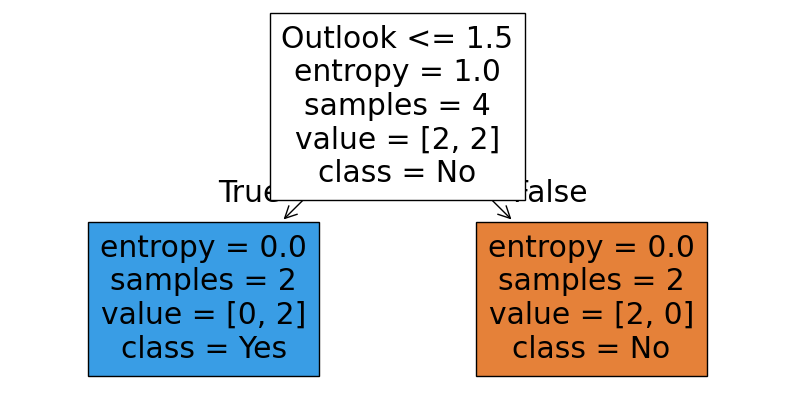

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

# Dataset
data = [
    ["Sunny","Hot","High","Weak","No"],
    ["Sunny","Hot","High","Strong","No"],
    ["Overcast","Hot","High","Weak","Yes"],
    ["Rain","Mild","High","Weak","Yes"]
]

cols = ["Outlook","Temperature","Humidity","Wind","Play"]
df = pd.DataFrame(data, columns=cols)

# Encode categorical columns
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Features and target
X = df.drop("Play", axis=1)
y = df["Play"]

# Train Decision Tree
model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X, y)

# Print tree as text
print("Decision Tree:\n")
print(export_text(model, feature_names=list(X.columns)))

# Plot tree
plt.figure(figsize=(10,5))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=encoders["Play"].classes_,
    filled=True
)
plt.show()

In [ ]:
# TO RUN ALL CELLS FOR OUTPUT

def run_all_tests():
    print("="*50 + "\n1. CENTRAL TENDENCY\n" + "="*50)
    data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    print(f"Data: {data}\nResult: {central_tendency(data)}\n")

    print("="*50 + "\n2. FIND-S AND CANDIDATE ELIMINATION\n" + "="*50)
    attrs = [['sunny', 'cloudy', 'rainy'], ['warm', 'cold'], ['high', 'normal']]
    ex = [(['sunny', 'warm', 'high'], 1),
          (['sunny', 'warm', 'normal'], 1),
          (['rainy', 'cold', 'high'], 0)]
    clf = ConceptLearning(attrs)
    print(f"Find-S Hypothesis: {clf.find_s(ex)}")
    S, G = clf.candidate_elimination(ex)
    print(f"Candidate Elimination -> S: {S}, G: {G}\n")

    print("="*50 + "\n3. BACKPROPAGATION (XOR Problem)\n" + "="*50)
    np.random.seed(42)
    X = np.array([[0.8, 0], [0.991, 1], [1.001, 0], [1.29, 1]])
    y = np.array([[0], [1], [0], [0]])
    nn = NeuralNetwork([2, 4, 1], lr=0.01)
    nn.train(X, y, epochs=2000)
    print(f"Predictions:\n{nn.predict(X).round(3)}\n")

    print("="*50 + "\n4. K-MEANS CLUSTERING\n" + "="*50)
    np.random.seed(42)
    X_km = np.vstack([np.random.randn(20, 2), np.random.randn(20, 2) + 5, np.random.randn(20, 2) + [0, 5]])
    kmeans = KMeans(k=3).fit(X_km)
    print(f"Centroids:\n{kmeans.c}")
    print(f"Labels distribution: {np.bincount(kmeans.labels_)}\n")

    print("="*50 + "\n5. KNN ALGORITHM\n" + "="*50)
    X_knn = np.array([[1, 2], [2, 3], [3, 4], [6, 7], [7, 8], [8, 9]])
    y_knn = np.array([0, 0, 0, 1, 1, 1])
    X_test = np.array([[2, 2], [7, 7]])
    knn = KNN(k=3).fit(X_knn, y_knn)
    print(f"Test points: {X_test.tolist()}")
    print(f"Predictions: {knn.predict(X_test)}\n")



# Execute the tests
run_all_tests()

1. CENTRAL TENDENCY
Data: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Result: {'mean': np.float64(55.0), 'median': np.float64(55.0), 'mode': np.int64(10), 'geometric_mean': np.float64(45.28728688116765), 'trimmed_mean': np.float64(55.0)}

2. FIND-S AND CANDIDATE ELIMINATION
Find-S Hypothesis: ['sunny', 'warm', '?']
Candidate Elimination -> S: ['sunny', 'warm', '?'], G: [['?', '?', '?']]

3. BACKPROPAGATION (XOR Problem)
Predictions:
[[0.061]
 [0.53 ]
 [0.045]
 [0.399]]

4. K-MEANS CLUSTERING
Centroids:
[[-0.17610301 -0.26117067]
 [ 4.95886859  5.07461057]
 [ 0.08577856  5.08608253]]
Labels distribution: [20 19 21]

5. KNN ALGORITHM
Test points: [[2, 2], [7, 7]]
Predictions: [0 1]

6. DECISION TREE
Training data: [2.5, 3.5, 4.5, 5.5, 6.5, 7.5]
Predictions: [0 0 0 1 1 1]

